In [2]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/thanh142005/datasetpoject/IMDB Dataset.csv


# Project giữa kỳ

# THƯ VIỆN

In [3]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, roc_curve, auc

sns.set_theme(style="whitegrid")

# ĐỌC VÀ TIỀN XỬ LÝ DỮ LIỆU

--- ĐỌC VÀ TIỀN XỬ LÝ DỮ LIỆU ---


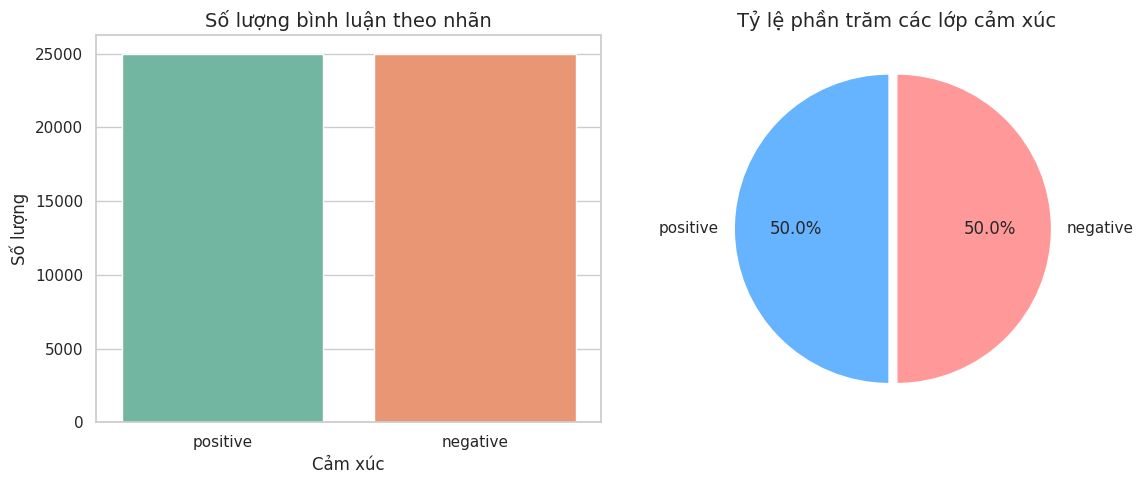

In [4]:
print("--- ĐỌC VÀ TIỀN XỬ LÝ DỮ LIỆU ---")
df = pd.read_csv("/kaggle/input/datasets/thanh142005/datasetpoject/IMDB Dataset.csv")

def clean_text(text):
    text = re.sub(r'<.*?>', ' ', text)
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    text = text.lower().strip()
    return text

df['cleaned_review'] = df['review'].apply(clean_text)

df['sentiment_encoded'] = df['sentiment'].map({'positive': 1, 'negative': 0})

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.countplot(x='sentiment', data=df, palette='Set2', hue='sentiment', legend=False)
plt.title('Số lượng bình luận theo nhãn', fontsize=14)
plt.xlabel('Cảm xúc', fontsize=12)
plt.ylabel('Số lượng', fontsize=12)

plt.subplot(1, 2, 2)
df['sentiment'].value_counts().plot.pie(autopct='%1.1f%%', colors=['#66b3ff','#ff9999'], startangle=90, explode=(0.05, 0))
plt.title('Tỷ lệ phần trăm các lớp cảm xúc', fontsize=14)
plt.ylabel('')

plt.tight_layout()
plt.show()

# TRÍCH XUẤT ĐẶC TRƯNG

In [5]:
print("--- TRÍCH XUẤT ĐẶC TRƯNG VỚI TF-IDF TỐI ƯU ---")

X = df['cleaned_review']
y = df['sentiment_encoded']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

tfidf = TfidfVectorizer(
    stop_words='english',
    ngram_range=(1, 2),
    max_features=10000,
    min_df=5,
    max_df=0.8
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print(f"Kích thước tập dữ liệu huấn luyện sau khi qua TF-IDF: {X_train_tfidf.shape}")
print(f"Kích thước tập dữ liệu kiểm thử sau khi qua TF-IDF: {X_test_tfidf.shape}")

--- TRÍCH XUẤT ĐẶC TRƯNG VỚI TF-IDF TỐI ƯU ---
Kích thước tập dữ liệu huấn luyện sau khi qua TF-IDF: (40000, 10000)
Kích thước tập dữ liệu kiểm thử sau khi qua TF-IDF: (10000, 10000)


# HUẤN LUYỆN CÁC MÔ HÌNH

In [6]:
print("--- HUẤN LUYỆN CÁC MÔ HÌNH ---")

print("Đang huấn luyện Logistic Regression...")
lr_model = LogisticRegression(C=1.0, max_iter=1000, random_state=42)
lr_model.fit(X_train_tfidf, y_train)
y_pred_lr = lr_model.predict(X_test_tfidf)
y_score_lr = lr_model.predict_proba(X_test_tfidf)[:, 1]

print("Đang huấn luyện SVM (LinearSVC)...")
svm_model = LinearSVC(C=0.1, max_iter=2000, random_state=42)
svm_model.fit(X_train_tfidf, y_train)
y_pred_svm = svm_model.predict(X_test_tfidf)
y_score_svm = svm_model.decision_function(X_test_tfidf)

print("Đang huấn luyện MLP Classifier...")
mlp_model = MLPClassifier(hidden_layer_sizes=(50,), max_iter=200, early_stopping=True, random_state=42)
mlp_model.fit(X_train_tfidf, y_train)
y_pred_mlp = mlp_model.predict(X_test_tfidf)
y_score_mlp = mlp_model.predict_proba(X_test_tfidf)[:, 1]

print("\n=== KẾT QUẢ BÁO CÁO CHI TIẾT (CLASSIFICATION REPORT) ===")
models_preds = {
    "Logistic Regression": y_pred_lr,
    "SVM (LinearSVC)": y_pred_svm,
    "MLP Classifier": y_pred_mlp
}

for name, preds in models_preds.items():
    print(f"\nMô hình: {name}")
    print(f"Độ chính xác tổng thể (Accuracy Score): {accuracy_score(y_test, preds):.4f}")
    print(classification_report(y_test, preds, target_names=['Negative', 'Positive']))

--- HUẤN LUYỆN CÁC MÔ HÌNH ---
Đang huấn luyện Logistic Regression...
Đang huấn luyện SVM (LinearSVC)...
Đang huấn luyện MLP Classifier...

=== KẾT QUẢ BÁO CÁO CHI TIẾT (CLASSIFICATION REPORT) ===

Mô hình: Logistic Regression
Độ chính xác tổng thể (Accuracy Score): 0.8979
              precision    recall  f1-score   support

    Negative       0.91      0.89      0.90      5000
    Positive       0.89      0.91      0.90      5000

    accuracy                           0.90     10000
   macro avg       0.90      0.90      0.90     10000
weighted avg       0.90      0.90      0.90     10000


Mô hình: SVM (LinearSVC)
Độ chính xác tổng thể (Accuracy Score): 0.8988
              precision    recall  f1-score   support

    Negative       0.91      0.89      0.90      5000
    Positive       0.89      0.91      0.90      5000

    accuracy                           0.90     10000
   macro avg       0.90      0.90      0.90     10000
weighted avg       0.90      0.90      0.90     10000


# ĐÁNH GIÁ VÀ TRỰC QUAN HÓA KẾT QUẢ

--- TRỰC QUAN HÓA KẾT QUẢ NÂNG CAO ---


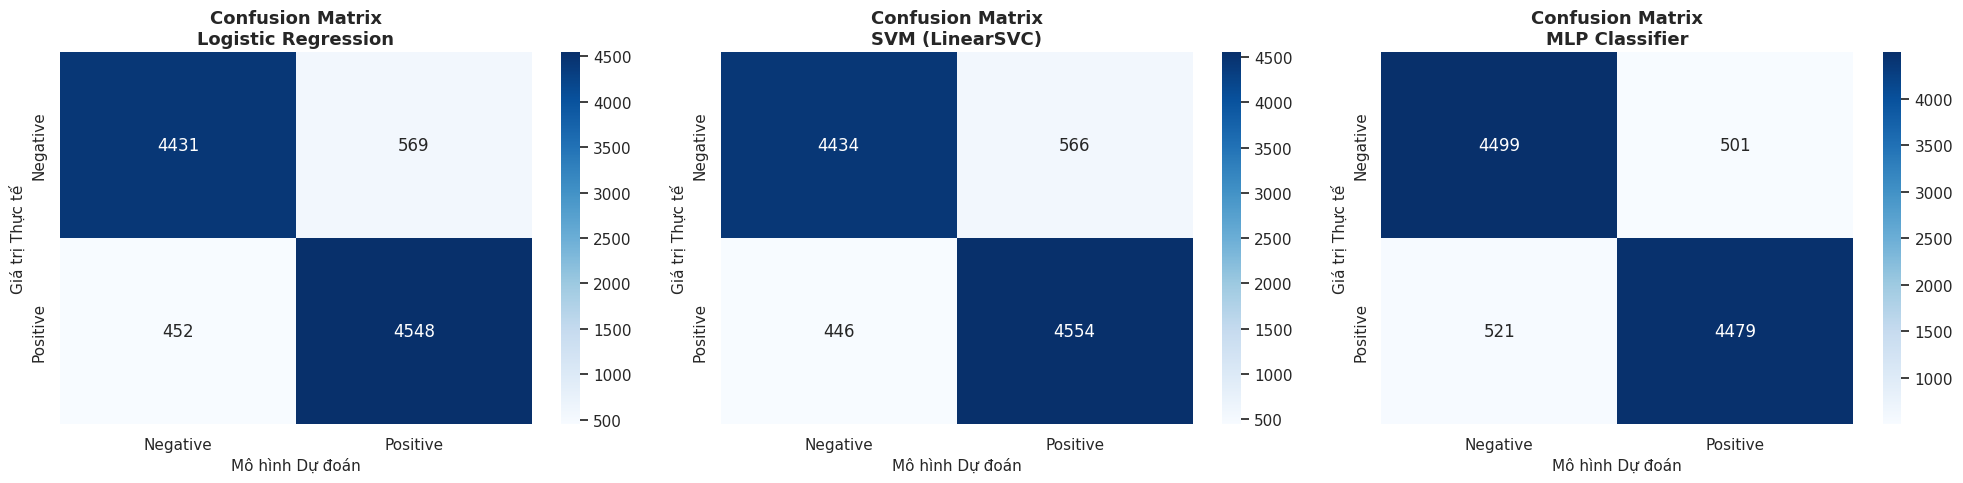

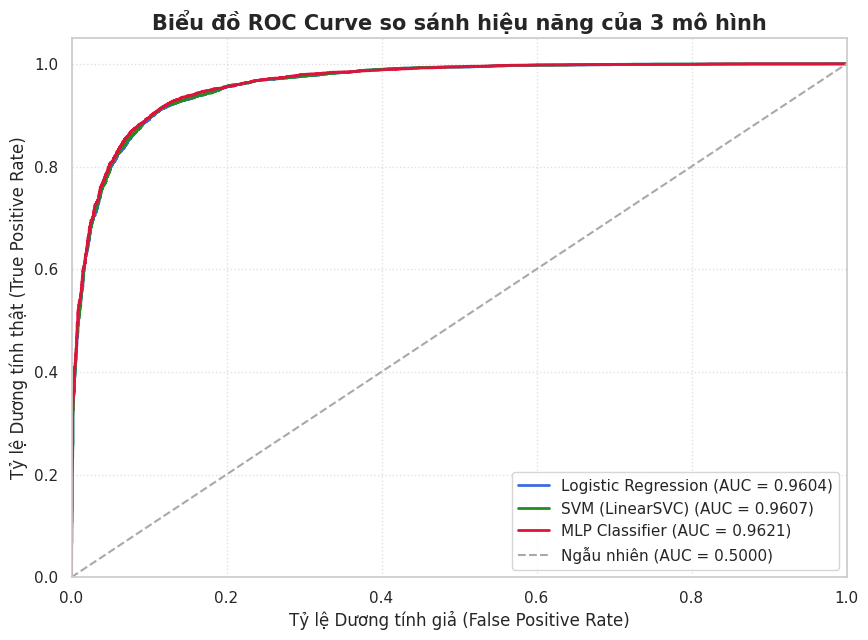

In [7]:
print("--- TRỰC QUAN HÓA KẾT QUẢ NÂNG CAO ---")

fig, axes = plt.subplots(1, 3, figsize=(20, 5))
models_info = [
    ("Logistic Regression", y_test, y_pred_lr, 0),
    ("SVM (LinearSVC)", y_test, y_pred_svm, 1),
    ("MLP Classifier", y_test, y_pred_mlp, 2)
]

for name, y_true, y_pred, idx in models_info:
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx],
                xticklabels=['Negative', 'Positive'], yticklabels=['Negative', 'Positive'])
    axes[idx].set_title(f'Confusion Matrix\n{name}', fontsize=13, fontweight='bold')
    axes[idx].set_xlabel('Mô hình Dự đoán', fontsize=11)
    axes[idx].set_ylabel('Giá trị Thực tế', fontsize=11)

plt.tight_layout()
plt.show()


plt.figure(figsize=(10, 7))

fpr_lr, tpr_lr, _ = roc_curve(y_test, y_score_lr)
auc_lr = auc(fpr_lr, tpr_lr)
plt.plot(fpr_lr, tpr_lr, label=f'Logistic Regression (AUC = {auc_lr:.4f})', color='royalblue', lw=2)

fpr_svm, tpr_svm, _ = roc_curve(y_test, y_score_svm)
auc_svm = auc(fpr_svm, tpr_svm)
plt.plot(fpr_svm, tpr_svm, label=f'SVM (LinearSVC) (AUC = {auc_svm:.4f})', color='forestgreen', lw=2)

fpr_mlp, tpr_mlp, _ = roc_curve(y_test, y_score_mlp)
auc_mlp = auc(fpr_mlp, tpr_mlp)
plt.plot(fpr_mlp, tpr_mlp, label=f'MLP Classifier (AUC = {auc_mlp:.4f})', color='crimson', lw=2)

plt.plot([0, 1], [0, 1], color='darkgray', linestyle='--', label='Ngẫu nhiên (AUC = 0.5000)')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Tỷ lệ Dương tính giả (False Positive Rate)', fontsize=12)
plt.ylabel('Tỷ lệ Dương tính thật (True Positive Rate)', fontsize=12)
plt.title('Biểu đồ ROC Curve so sánh hiệu năng của 3 mô hình', fontsize=15, fontweight='bold')
plt.legend(loc="lower right", fontsize=11)
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

# DỰ ĐOÁN CẢM XÚC CÁC BÌNH LUẬN MỚI

In [8]:
def predict_new_reviews(reviews_list):
    print("\n--- DỰ ĐOÁN CẢM XÚC CÁC BÌNH LUẬN MỚI ---")
    
    cleaned_reviews = [clean_text(rev) for rev in reviews_list]
    
    reviews_tfidf = tfidf.transform(cleaned_reviews)
    
    preds_lr = lr_model.predict(reviews_tfidf)
    preds_svm = svm_model.predict(reviews_tfidf)
    preds_mlp = mlp_model.predict(reviews_tfidf)
    
    for i, review in enumerate(reviews_list):
        print(f"\nNội dung bình luận: \"{review}\"")
        print(f" ==> Logistic Regression dự đoán: {'TÍCH CỰC (Positive)' if preds_lr[i] == 1 else 'TIÊU CỰC (Negative)'}")
        print(f" ==> SVM (LinearSVC) dự đoán:    {'TÍCH CỰC (Positive)' if preds_svm[i] == 1 else 'TIÊU CỰC (Negative)'}")
        print(f" ==> MLP Classifier dự đoán:     {'TÍCH CỰC (Positive)' if preds_mlp[i] == 1 else 'TIÊU CỰC (Negative)'}")

sample_reviews = [
    "This movie was an absolute masterpiece! The acting was phenomenal and the plot kept me hooked till the end.",
    "Waste of time and money. The story makes no sense, and the main actor's performance was completely boring.",
    "It was okay, not the best film I've ever seen but it had some funny moments."
]

predict_new_reviews(sample_reviews)


--- DỰ ĐOÁN CẢM XÚC CÁC BÌNH LUẬN MỚI ---

Nội dung bình luận: "This movie was an absolute masterpiece! The acting was phenomenal and the plot kept me hooked till the end."
 ==> Logistic Regression dự đoán: TÍCH CỰC (Positive)
 ==> SVM (LinearSVC) dự đoán:    TÍCH CỰC (Positive)
 ==> MLP Classifier dự đoán:     TÍCH CỰC (Positive)

Nội dung bình luận: "Waste of time and money. The story makes no sense, and the main actor's performance was completely boring."
 ==> Logistic Regression dự đoán: TIÊU CỰC (Negative)
 ==> SVM (LinearSVC) dự đoán:    TIÊU CỰC (Negative)
 ==> MLP Classifier dự đoán:     TIÊU CỰC (Negative)

Nội dung bình luận: "It was okay, not the best film I've ever seen but it had some funny moments."
 ==> Logistic Regression dự đoán: TÍCH CỰC (Positive)
 ==> SVM (LinearSVC) dự đoán:    TÍCH CỰC (Positive)
 ==> MLP Classifier dự đoán:     TÍCH CỰC (Positive)
